# GPU vs CPU Monte Carlo Demo (on Apple Silicon)

This notebook compares a simple Monte Carlo estimator implemented in two ways:

1. **CPU (NumPy, float64)** – baseline, traditional scientific computing.
2. **GPU (PyTorch on MPS, float32)** – uses the Apple Silicon GPU via the Metal backend.

We estimate
\begin{equation}
I_d = \mathbb{E}\left[ \frac{e^{-\tfrac12\lVert X \rVert^2}}{2^{-d/2}} \right], \quad X \sim \mathcal{N}(0, I_d),
\end{equation}
where the factor $2^{-d/2}$ is chosen so that
\begin{equation}
I_d \equiv 1 \quad \text{for all dimensions } d.
\end{equation}

Thus the **exact value is 1**, independent of `d`, which makes it easy to interpret absolute errors
as `|estimate − 1|`.

For each sample size `n` we run the experiment **multiple times** (`M` replications) and record only
the **empirical errors** (no standard errors or confidence intervals).


## 1. Imports and device check

You need **PyTorch** installed with Apple Silicon / MPS support. If `torch.backends.mps.is_available()`
is `False`, the GPU run will fall back to CPU so you will not see a real GPU speed-up.


In [1]:
import time
import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device:", device)
else:
    device = torch.device("cpu")
    print("MPS not available – using CPU only (no real GPU speed-up will be visible).")


NumPy version: 2.3.2
PyTorch version: 2.8.0
Using device: mps


## 2. Monte Carlo estimators (rescaled so exact value is 1)

We implement the same Monte Carlo estimator three times:

- `mc_cpu_float64`: uses **NumPy** on CPU with `float64`.
- `mc_cpu_float32`: uses **NumPy** on CPU with `float32`.
- `mc_gpu_float32`: uses **PyTorch** on `device` (preferably MPS/GPU) with `float32`.

For each sample we compute
\begin{equation}
f(X) = \frac{e^{-\tfrac12\lVert X \rVert^2}}{2^{-d/2}},
\end{equation}
so that the exact expectation is 1 for all `d`.


In [2]:
def mc_cpu_float64(n: int, d: int) -> float:
    """Monte Carlo estimator on CPU using NumPy float64, rescaled so true value is 1."""
    # Normalization constant so that E[exp(-0.5||X||^2)/norm_const] = 1
    norm_const = (1 / np.sqrt(2.0)) ** d  # 2^(-d/2)
    x = np.random.normal(size=(n, d)).astype(np.float64)
    vals = np.exp(-0.5 * np.sum(x ** 2, axis=1)) / norm_const
    return float(vals.mean())

def mc_cpu_float32(n: int, d: int) -> float:
    """Monte Carlo estimator on CPU using NumPy float32, rescaled so true value is 1."""
    norm_const = (1 / np.sqrt(2.0)) ** d  # 2^(-d/2)
    x = np.random.normal(size=(n, d)).astype(np.float32)
    # Compute squared norms in float32
    sq = np.sum(x ** 2, axis=1, dtype=np.float32)
    vals = np.exp(-0.5 * sq).astype(np.float32) / np.float32(norm_const)
    return float(vals.mean(dtype=np.float32))

def mc_gpu_float32(n: int, d: int) -> float:
    """Monte Carlo estimator on GPU/CPU using PyTorch float32, rescaled so true value is 1.

    If `device` is "mps", this uses the Apple Silicon GPU via Metal.
    """
    norm_const = (1.0 / np.sqrt(2.0)) ** d
    norm_const_t = torch.tensor(norm_const, device=device, dtype=torch.float32)

    x = torch.randn((n, d), device=device, dtype=torch.float32)
    vals = torch.exp(-0.5 * torch.sum(x ** 2, dim=1)) / norm_const_t
    return float(vals.mean().item())


def time_run(func, *args, **kwargs):
    """Utility to time a function call and return (value, elapsed_seconds)."""
    t0 = time.perf_counter()
    val = func(*args, **kwargs)
    t1 = time.perf_counter()
    return val, t1 - t0


## 3. Parameters: dimension, sample sizes, and replications

- `d` – dimension of the normal vector.
- `ns` – list of sample sizes.
- `R` – number of **independent replications** per `(n, device)` combination.


In [3]:
d = 20                 # dimension of the normal vector
ns = [10_000, 100_000, 1_000_000]
R = 20                 # number of replications per n (change as desired)

exact_value = 1.0
print("Dimension d =", d)
print("Sample sizes n =", ns)
print("Number of replications R =", R)
print("Exact value (all d):", exact_value)


Dimension d = 20
Sample sizes n = [10000, 100000, 1000000]
Number of replications R = 20
Exact value (all d): 1.0


## 4. Run experiments with replications

For each `n` and each device (CPU / GPU) we perform `R` independent runs, and record:

- the estimate,
- the absolute error `|estimate − 1|`,
- the runtime.

We store all runs in a long-format DataFrame `df_runs`, and then compute summary statistics
by grouping over `(n, device)`.


In [7]:
records = []

for n in ns:
    for r in range(R):
        # CPU float64 run
        val_cpu64, t_cpu64 = time_run(mc_cpu_float64, n, d)
        err_cpu64 = abs(val_cpu64 - exact_value)
        records.append(
            {
                "n": n,
                "rep": r,
                "device": "CPU64",
                "value": val_cpu64,
                "abs_error": err_cpu64,
                "time_s": t_cpu64,
            }
        )

        # CPU float32 run
        val_cpu32, t_cpu32 = time_run(mc_cpu_float32, n, d)
        err_cpu32 = abs(val_cpu32 - exact_value)
        records.append(
            {
                "n": n,
                "rep": r,
                "device": "CPU32",
                "value": val_cpu32,
                "abs_error": err_cpu32,
                "time_s": t_cpu32,
            }
        )

        # GPU float32 run
        val_gpu32, t_gpu32 = time_run(mc_gpu_float32, n, d)
        err_gpu32 = abs(val_gpu32 - exact_value)
        records.append(
            {
                "n": n,
                "rep": r,
                "device": "GPU32",
                "value": val_gpu32,
                "abs_error": err_gpu32,
                "time_s": t_gpu32,
            }
        )

df_runs = pd.DataFrame.from_records(records)
df_runs.head()


,n,rep,device,value,abs_error,time_s
0,10000,0,CPU64,1.061939,0.061939,0.003015
1,10000,0,CPU32,1.068889,0.068889,0.002737
2,10000,0,GPU32,0.919378,0.080622,0.005201
3,10000,1,CPU64,1.046523,0.046523,0.002993
4,10000,1,CPU32,0.927292,0.072708,0.002806


### Summary table over replications

We summarize by `(n, device)` to get:

- average absolute error across replications,
- median, minimum, and maximum absolute error,
- average runtime,
- an average speed-up factor (CPU mean time / GPU mean time) for each `n`.


In [8]:
summary = (
    df_runs
    .groupby(["n", "device"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        min_abs_error=("abs_error", "min"),
        max_abs_error=("abs_error", "max"),
        mean_time_s=("time_s", "mean"),
    )
)

# Compute mean speed-up per n: CPU64_mean_time / GPU32_mean_time
speedup_records = []
for n in ns:
    row_cpu64 = summary[(summary["n"] == n) & (summary["device"] == "CPU64")]
    row_gpu32 = summary[(summary["n"] == n) & (summary["device"] == "GPU32")]
    if not row_cpu64.empty and not row_gpu32.empty:
        cpu_t = float(row_cpu64["mean_time_s"].iloc[0])
        gpu_t = float(row_gpu32["mean_time_s"].iloc[0])
        speedup = cpu_t / gpu_t if gpu_t > 0 else np.nan
        speedup_records.append({"n": n, "mean_speedup_CPU64_over_GPU32": speedup})

df_speedup = pd.DataFrame(speedup_records)
summary_merged = summary.merge(df_speedup, on="n", how="left")
summary_merged


,n,device,mean_abs_error,median_abs_error,min_abs_error,max_abs_error,mean_time_s,mean_speedup_CPU64_over_GPU32
0,10000,CPU32,0.038037,0.036050,0.005477,0.073794,0.002910,1.823594
1,10000,CPU64,0.036484,0.034677,0.001399,0.091999,0.002950,1.823594
2,10000,GPU32,0.026475,0.022557,0.000166,0.080622,0.001618,1.823594
3,100000,CPU32,0.010807,0.010953,0.000513,0.027133,0.026159,12.495218
4,100000,CPU64,0.011971,0.013394,0.000348,0.024258,0.025327,12.495218
5,100000,GPU32,0.010553,0.008897,0.001337,0.026766,0.002027,12.495218
6,1000000,CPU32,0.003014,0.002262,0.000197,0.011693,0.263849,63.732668
7,1000000,CPU64,0.003432,0.002448,0.000045,0.009069,0.277753,63.732668
8,1000000,GPU32,0.003856,0.003556,0.000473,0.009077,0.004358,63.732668


## 5. Runtime comparison (mean over replications)

We plot the **mean runtime** for CPU and GPU at each `n`.


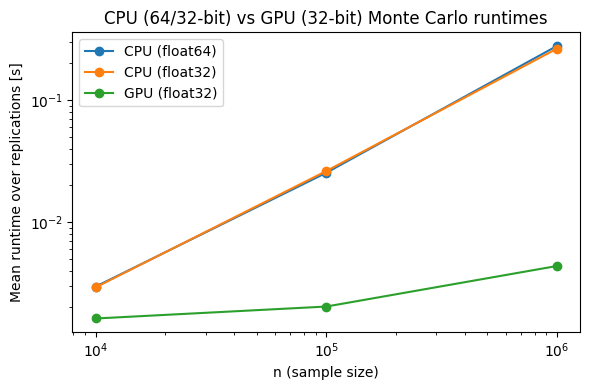

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

for device_name, label in [
    ("CPU64", "CPU (float64)"),
    ("CPU32", "CPU (float32)"),
    ("GPU32", "GPU (float32)"),
]:
    sub = summary[summary["device"] == device_name]
    ax.plot(sub["n"], sub["mean_time_s"], marker="o", label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (sample size)")
ax.set_ylabel("Mean runtime over replications [s]")
ax.set_title("CPU (64/32-bit) vs GPU (32-bit) Monte Carlo runtimes")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Error comparison (empirical errors only)

We now compare **absolute errors**. We do not compute standard errors or confidence
intervals; we only use empirical errors from the runs.

First we plot the **mean absolute error** over replications as a function of `n` for each device
on a log–log scale.


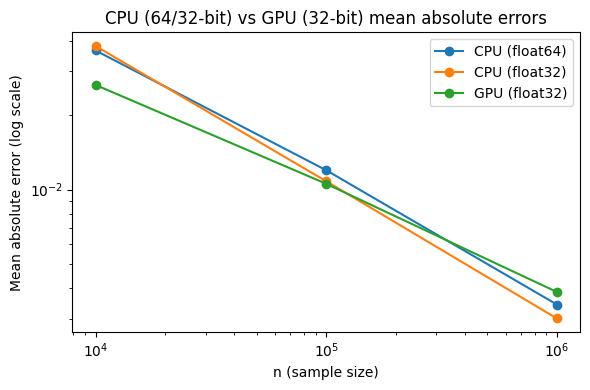

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

for device_name, label in [
    ("CPU64", "CPU (float64)"),
    ("CPU32", "CPU (float32)"),
    ("GPU32", "GPU (float32)"),
]:
    sub = summary[summary["device"] == device_name]
    ax.plot(sub["n"], sub["mean_abs_error"], marker="o", label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (sample size)")
ax.set_ylabel("Mean absolute error (log scale)")
ax.set_title("CPU (64/32-bit) vs GPU (32-bit) mean absolute errors")
ax.legend()
plt.tight_layout()
plt.show()


### Optional: scatter of individual absolute errors (log y-axis)

This plot shows all individual absolute errors for each `(n, device)` as jittered points on a
logarithmic vertical scale, to illustrate the spread of empirical errors across replications.


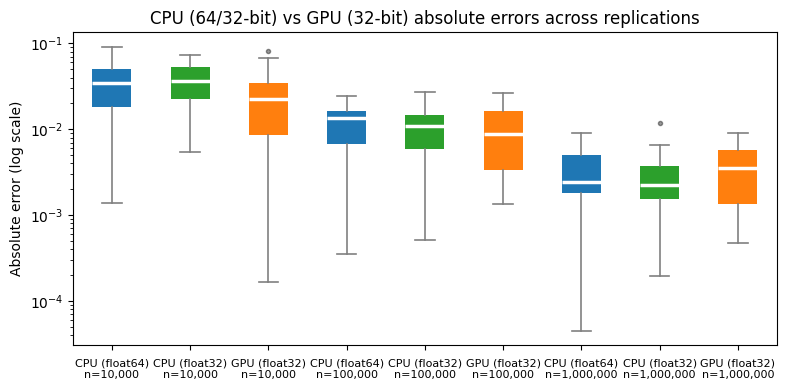

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

# In df_runs we now have devices: "CPU64", "CPU32", "GPU32"
device_order = [
    ("CPU64", "CPU (float64)"),
    ("CPU32", "CPU (float32)"),
    ("GPU32", "GPU (float32)"),
]

boxdata = []
labels = []

for n in ns:
    for dev_key, dev_label in device_order:
        sub = df_runs[(df_runs["n"] == n) & (df_runs["device"] == dev_key)]
        if sub.empty:
            continue  # just in case
        boxdata.append(sub["abs_error"].to_numpy())
        labels.append(f"{dev_label}\nn={n:,}")

# Colors repeating in the same order: CPU64, CPU32, GPU32 for each n
base_colors = ["tab:blue", "tab:green", "tab:orange"]
colors = [base_colors[i % len(base_colors)] for i in range(len(boxdata))]

bp = ax.boxplot(
    boxdata,
    patch_artist=True,
    tick_labels=labels,
    medianprops=dict(color="white", linewidth=2.5),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
)

# Apply multiline tick labels with improved spacing
ax.set_xticklabels(labels, fontsize=8, rotation=0, ha="center")
ax.tick_params(axis='x', pad=6)

# Style boxes and medians
for patch, color in zip(bp["boxes"], colors):
    patch.set_edgecolor("none")
    patch.set_facecolor(color)

for median, color in zip(bp["medians"], colors):
    median.set_color("white")
    median.set_linewidth(2.5)

for flier in bp["fliers"]:
    flier.set_marker(".")
    flier.set_markersize(6)
    flier.set_markerfacecolor("black")
    flier.set_alpha(0.4)

ax.set_yscale("log")
ax.set_ylabel("Absolute error (log scale)")
ax.set_title("CPU (64/32-bit) vs GPU (32-bit) absolute errors across replications")

plt.tight_layout()
plt.show()

## 7. Discussion

- The integral was rescaled so that the exact value is **1**, making absolute error easy to interpret.
- For each `n`, we ran `R` independent replications for CPU and GPU and looked only at **empirical**
  errors `|estimate − 1|` (no standard errors or confidence intervals).
- On an Apple Silicon MacBook Pro with MPS enabled, you should see:
  - The GPU achieving noticeably smaller **mean runtime** for large `n`.
  - CPU and GPU **mean absolute errors** of similar magnitude for each `n`.
  - The error decreasing roughly like $n^{-1/2}$ on the log–log plot.
- Any unusually small error at a given `n` and device is usually due to **Monte Carlo luck**, not
  a fundamental accuracy difference between float32 and float64 for this smooth problem.


## 8. Many Expectations in Parallel (GPU-friendly batch example)

So far we estimated a **single expectation** on CPU vs GPU.
In many real applications we need the same kind of expectation for **many parameter values**.

Here we consider expectations of the form
\begin{equation}
I(a) = \mathbb{E}\left[ f_a(X) \right], \quad X \sim \mathcal{N}(0, I_d),
\end{equation}
where
\begin{equation}
f_a(X) = \frac{\exp\big(-\tfrac{1}{2}\lVert X - a \rVert^2\big)}{2^{-d/2}\,\exp(-\lVert a \rVert^2/4)}.
\end{equation}
One can show that this normalization makes
$$ I(a) = 1 \quad \text{for all } a \in \mathbb{R}^d. $$

We now choose **many centers** $a_1, \dots, a_M$ and estimate all $I(a_j)$ at once.
This is very natural for a GPU, which can process the resulting large tensor of
values in parallel.


### 8.1 Helper functions for many expectations

We implement CPU and GPU versions that, given:

- a sample size `n`,
- a dimension `d`,
- a matrix of centers `A` of shape `(M, d)`,

return **all** Monte Carlo estimates `[I(a_1), …, I(a_M)]`.


In [12]:
import numpy as np
import torch
import time

def mc_many_cpu_float64(n: int, d: int, A: np.ndarray) -> np.ndarray:
    """Compute M expectations on CPU using NumPy float64.

    A has shape (M, d). Returns an array of shape (M,) with one estimate per center.
    Each expectation is normalized so that the true value is 1 for all a.
    """
    A = np.asarray(A, dtype=np.float64)
    M_centers = A.shape[0]

    # Normalization constants: 2^(-d/2) * exp(-||a||^2 / 4) for each center a
    norm_const = (2.0 ** (-d / 2.0)) * np.exp(-0.25 * np.sum(A ** 2, axis=1))  # (M,)

    # Draw samples X ~ N(0, I_d)
    X = np.random.normal(size=(n, d)).astype(np.float64)  # (n, d)

    # Broadcast to (M, n, d): X_i - a_j
    diff = X[None, :, :] - A[:, None, :]  # (M, n, d)
    sqnorm = np.sum(diff ** 2, axis=-1)   # (M, n)
    vals = np.exp(-0.5 * sqnorm) / norm_const[:, None]

    return vals.mean(axis=1)  # (M,)


def mc_many_gpu_float32(n: int, d: int, A_torch: torch.Tensor, device: torch.device) -> torch.Tensor:
    """Compute M expectations on GPU/CPU using PyTorch float32.

    A_torch has shape (M, d) on the given device. Returns a tensor of shape (M,).
    Each expectation is normalized so that the true value is 1 for all a.
    """
    A_torch = A_torch.to(device=device, dtype=torch.float32)
    M_centers = A_torch.shape[0]

    # Normalization constants: 2^(-d/2) * exp(-||a||^2 / 4) for each center a
    norm_const = (2.0 ** (-d / 2.0)) * torch.exp(-0.25 * torch.sum(A_torch ** 2, dim=1))  # (M,)
    norm_const = norm_const.view(M_centers, 1)  # (M, 1) for broadcasting

    # Draw samples X ~ N(0, I_d) on the device
    X = torch.randn((n, d), device=device, dtype=torch.float32)  # (n, d)

    # Broadcast to (M, n, d): X_i - a_j
    diff = X.unsqueeze(0) - A_torch.unsqueeze(1)  # (M, n, d)
    sqnorm = torch.sum(diff ** 2, dim=-1)        # (M, n)
    vals = torch.exp(-0.5 * sqnorm) / norm_const

    return vals.mean(dim=1)  # (M,)


def time_run(func, *args, **kwargs):
    """Utility to time a function call and return (value, elapsed_seconds)."""
    t0 = time.perf_counter()
    val = func(*args, **kwargs)
    t1 = time.perf_counter()
    return val, t1 - t0


### 8.2 Timing many expectations: CPU vs GPU

We now fix a dimension `d` and a number of samples `n`, and increase the number of
centers `M`. The GPU will handle the batch `(M, n, d)` much more gracefully than
the CPU, especially as `M` becomes large.  In this case we only do `R=1` replication.

We also check that all estimated expectations stay close to 1, confirming that the
normalization is correct.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Dimension and sample size for this experiment
d_many = 20
n_many = 200_000

# Different numbers of centers M to try
Ms = [1, 5, 10, 20, 50, 100, 200, 500, 1000]

# Generate a fixed bank of centers A_max, to be shared between CPU and GPU
M_max = max(Ms)
A_np = np.random.normal(size=(M_max, d_many))  # (M_max, d)

# Torch version of centers (we'll slice as needed)
A_torch = torch.from_numpy(A_np)

records_many = []

for M_centers in Ms:
    A_slice_np = A_np[:M_centers, :]
    A_slice_torch = A_torch[:M_centers, :]   # stay on CPU for now; function will move & cast

    # CPU timing
    est_cpu, t_cpu = time_run(mc_many_cpu_float64, n_many, d_many, A_slice_np)
    # GPU timing
    est_gpu_t, t_gpu = time_run(mc_many_gpu_float32, n_many, d_many, A_slice_torch, device)
    est_gpu = est_gpu_t.cpu().numpy()
    
    # Mean absolute error over the M centers (true value is 1 for each)
    cpu_mean_abs_err = float(np.mean(np.abs(est_cpu - 1.0)))
    gpu_mean_abs_err = float(np.mean(np.abs(est_gpu - 1.0)))

    records_many.append(
        {
            "M_centers": M_centers,
            "CPU time [s]": t_cpu,
            "GPU time [s]": t_gpu,
            "speedup (CPU/GPU)": t_cpu / t_gpu if t_gpu > 0 else np.nan,
            "CPU mean |error|": cpu_mean_abs_err,
            "GPU mean |error|": gpu_mean_abs_err,
        }
    )

df_many = pd.DataFrame.from_records(records_many)
df_many

,M_centers,CPU time [s],GPU time [s],speedup (CPU/GPU),CPU mean |error|,GPU mean |error|
0,1,0.061985,0.004118,15.051542,0.055886,0.017250
1,5,0.093081,0.001326,70.197179,0.038064,0.029286
2,10,0.133653,0.001185,112.791516,0.037577,0.028205
3,20,0.235091,0.001070,219.762288,0.047502,0.031116
4,50,0.503435,0.001303,386.279322,0.058536,0.048457
5,100,1.020347,0.001135,898.687108,0.045540,0.035739
6,200,1.959248,0.002442,802.408596,0.038215,0.040093
7,500,5.821433,0.003974,1464.726241,0.041616,0.041901
8,1000,29.145692,0.018881,1543.614411,0.045501,0.044601


### 8.3 Plots for many expectations

We now visualize the runtime and the average absolute error for CPU and GPU as the
number of centers `M` increases.


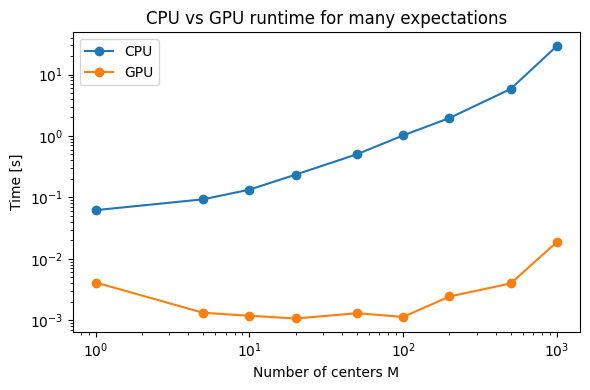

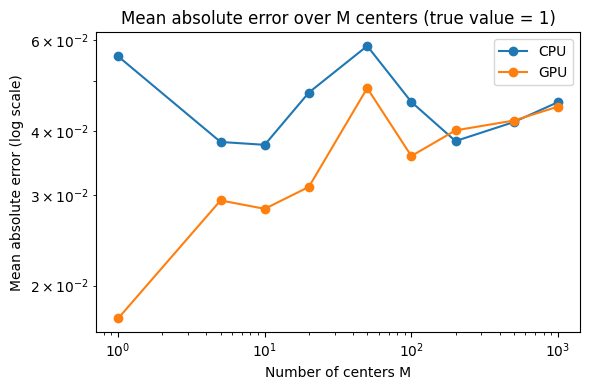

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_many["M_centers"], df_many["CPU time [s]"], marker="o", label="CPU")
ax.plot(df_many["M_centers"], df_many["GPU time [s]"], marker="o", label="GPU")

ax.set_xlabel("Number of centers M")
ax.set_ylabel("Time [s]")
ax.set_title("CPU vs GPU runtime for many expectations")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_many["M_centers"], df_many["CPU mean |error|"], marker="o", label="CPU")
ax.plot(df_many["M_centers"], df_many["GPU mean |error|"], marker="o", label="GPU")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of centers M")
ax.set_ylabel("Mean absolute error (log scale)")
ax.set_title("Mean absolute error over M centers (true value = 1)")
ax.legend()
plt.tight_layout()
plt.show()
